# mtDSB x Age DE analysis (pydeseq2, LRT-free)

In [22]:
import pandas as pd
import numpy as np
from scipy import sparse

from anndata import AnnData
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats
import scanpy as sc
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "utils")))
from analysis_utils import (
    volcano_plot_br,
    plot_spatial_clusters_per_sample,
    plot_dotplot_by_treatment,
    plot_relative_cluster_composition
)

def make_pseudobulk_per_sample(adata, layer="counts"):
    """Sum all counts per sample_id."""
    if layer in adata.layers:
        X = adata.layers[layer]
    else:
        X = adata.X

    if sparse.issparse(X):
        X = X.toarray()

    sample_ids = adata.obs["sample_id"].astype(str)
    uniq_samples = sample_ids.unique()

    pb = {}
    for sid in uniq_samples:
        mask = sample_ids == sid
        pb[sid] = X[mask, :].sum(axis=0)

    counts_df = pd.DataFrame(pb, index=adata.var_names)
    meta_df = (
        adata.obs.groupby("sample_id")
        .agg({"treatment": "first"})
        .rename(columns={"treatment": "condition"})
    )

    return counts_df, meta_df

## Read data

In [5]:
adata = sc.read_h5ad('../data/ST_BRICHOS_region_subcluster.h5ad')

In [6]:
adata.X = adata.layers['counts']
adata.X = adata.X.astype(int)

In [7]:
adata = adata[adata.obs.treatment.isin(['BRICHOS','WT'])]

## Perform pseudobulk

In [8]:
dict(zip(adata.obs['sample_id'], adata.obs['treatment']))

{'P24215_301': 'BRICHOS',
 'P24215_101': 'WT',
 'P28052_401': 'BRICHOS',
 'P24215_201': 'BRICHOS'}

In [9]:
counts_df, meta_df = make_pseudobulk_per_sample(adata, layer="counts")

## Perform DGE


In [10]:
# Convert pseudobulk to AnnData (samples x genes)
ad = AnnData(X=counts_df.T.values)
ad.var_names = counts_df.index
ad.obs_names = counts_df.columns
ad.obs = meta_df.copy()

# Build and run DESeq2
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=ad,
    design_factors=["condition"],
    refit_cooks=True,
    inference=inference,
)
dds.deseq2()

# Contrast BRICHOS vs WT
stat_res = DeseqStats(dds, contrast=["condition", "BRICHOS", "WT"], inference=inference)
stat_res.summary()

# Extract results
res = stat_res.results_df
res.head()

Using None as control genes, passed at DeseqDataSet initialization


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:774: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['P24215_301', 'P24215_101', 'P28052_401', 'P24215_201']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_90623/1952918206.py:9: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.01 seconds.

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: overflow encountered in matmul
  

Log2 fold change & Wald test p-value: condition BRICHOS vs WT
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4            669.811384       -0.156757  0.250258 -0.626382  0.531065   
Rp1              16.254961       -0.070456  1.090758 -0.064594  0.948497   
Sox17           348.829473        0.035745  0.295991  0.120763  0.903879   
Lypla1         1205.599888       -0.243949  0.183346 -1.330543  0.183340   
Tcea1          3031.401507       -0.159376  0.151399 -1.052690  0.292483   
...                    ...             ...       ...       ...       ...   
Arhgap6         578.715788        0.204441  0.287110  0.712064  0.476425   
Hccs           1641.780299        0.034141  0.166429  0.205137  0.837465   
Mid1            225.516837        0.646592  0.530696  1.218385  0.223078   
4933400A11Rik     1.095900        0.464984  4.589552  0.101314  0.919301   
Asmt              8.076342       -0.453288  1.496094 -0.302981  0.761904   

                   padj  

... done in 0.33 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Xkr4,669.811384,-0.156757,0.250258,-0.626382,0.531065,0.999869
Rp1,16.254961,-0.070456,1.090758,-0.064594,0.948497,0.999869
Sox17,348.829473,0.035745,0.295991,0.120763,0.903879,0.999869
Lypla1,1205.599888,-0.243949,0.183346,-1.330543,0.183340,0.999869
Tcea1,3031.401507,-0.159376,0.151399,-1.052690,0.292483,0.999869


In [40]:
# Top upregulated
res.sort_values("log2FoldChange", ascending=False).head(10)

# Top downregulated
res.sort_values("log2FoldChange", ascending=True).head(10)

# Significant hits
sig = res.query("padj < 0.05")
print(f"Significant DEGs: {sig.shape[0]}")

Significant DEGs: 46


In [41]:
sig = sig.sort_values(by = 'log2FoldChange',ascending = False)

In [44]:
outdir = "../results/DGE"
os.makedirs(outdir, exist_ok=True)
sig.to_csv('../results/DGE/BRICHOS-wt-sig.csv')
res.to_csv('../results/DGE/BRICHOS-wt-all.csv')

In [45]:
sig.head(50)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Cst7,1273.491760,6.722796,0.380292,17.677998,6.195700e-70,1.036417e-65
Itgax,80.214678,5.388952,0.968180,5.566062,2.605606e-08,2.075551e-05
Ccl3,94.315942,4.883393,0.805879,6.059711,1.363662e-09,1.267296e-06
Ccl6,684.409196,3.303398,0.248282,13.305015,2.164492e-40,1.810381e-36
Cxcl5,119.850282,2.853963,0.720415,3.961554,7.446350e-05,3.038111e-02
Cd52,605.266282,1.976794,0.238385,8.292425,1.109624e-16,3.712356e-13
Tyrobp,1743.467914,1.883567,0.172795,10.900615,1.144809e-27,6.383458e-24
Gfap,9912.419401,1.673474,0.196814,8.502817,1.850440e-17,7.738541e-14
Myo1f,261.939308,1.600347,0.313728,5.101065,3.377476e-07,2.354101e-04
C3ar1,322.936474,1.596137,0.302179,5.282083,1.277231e-07,9.711598e-05


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from adjustText import adjust_text  # pip install adjustText

def volcano_pretty(
    res,
    lfc_col="log2FoldChange",
    p_col="pvalue",
    padj_col="padj",
    lfc_thr=1.0,
    padj_thr=0.05,
    top_labels=15,
    title="Volcano: BRICHOS vs WT",
    figsize=(7, 6),
):
    """Beautiful volcano plot with smart labeling."""
    df = res.copy()
    df["neglog10p"] = -np.log10(df[p_col] + 1e-300)

    # significance flags
    sig = (df[padj_col] < padj_thr) & (df[lfc_col].abs() >= lfc_thr)
    up = sig & (df[lfc_col] > 0)
    dn = sig & (df[lfc_col] < 0)
    ns = ~sig

    # size scaling by significance
    df["size"] = np.clip(df["neglog10p"] / df["neglog10p"].max() * 60, 8, 60)

    # --- Plot ---
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=figsize)

    # non-significant
    ax.scatter(
        df.loc[ns, lfc_col],
        df.loc[ns, "neglog10p"],
        s=df.loc[ns, "size"],
        c="lightgrey",
        alpha=0.5,
        lw=0,
    )

    # down
    ax.scatter(
        df.loc[dn, lfc_col],
        df.loc[dn, "neglog10p"],
        s=df.loc[dn, "size"],
        c="#4575b4",
        alpha=0.8,
        lw=0,
        label=f"down (n={dn.sum()})",
    )

    # up
    ax.scatter(
        df.loc[up, lfc_col],
        df.loc[up, "neglog10p"],
        s=df.loc[up, "size"],
        c="#d73027",
        alpha=0.8,
        lw=0,
        label=f"up (n={up.sum()})",
    )

    # threshold lines
    ax.axvline(lfc_thr, color="k", lw=0.8, ls="--")
    ax.axvline(-lfc_thr, color="k", lw=0.8, ls="--")
    ax.axhline(-np.log10(padj_thr), color="k", lw=0.8, ls="--")

    # highlight top genes
    top = df.sort_values(p_col).head(top_labels)
    texts = []
    for _, r in top.iterrows():
        gene_name = r.name if not hasattr(r, "gene") else r.get("gene", r.name)
        texts.append(
            ax.text(
                r[lfc_col],
                r["neglog10p"],
                gene_name,
                fontsize=8,
                color="black",
                ha="left",
                va="bottom",
            )
        )
    adjust_text(texts, arrowprops=dict(arrowstyle="-", lw=0.3, color="gray"))

    # styling
    ax.set_xlabel("log2 fold change (BRICHOS vs WT)", fontsize=11)
    ax.set_ylabel("−log10(p-value)", fontsize=11)
    ax.set_title(title, fontsize=13, pad=15)
    ax.legend(frameon=False, fontsize=9, loc="upper left")
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

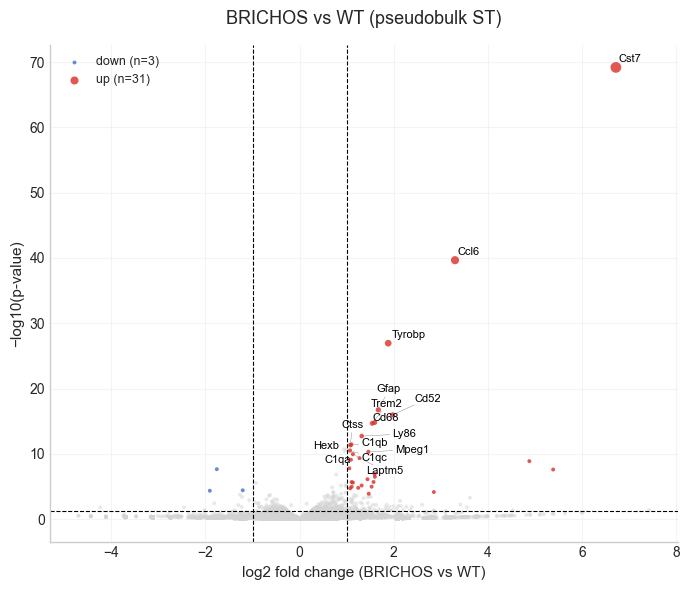

In [35]:
volcano_pretty(res, title="BRICHOS vs WT (pseudobulk ST)")